In [ ]:
import pandas as pd

# Path to data frame with WSIs
abmil_training = r"D:\DATA\EXP3_abmil\abmil_training.csv"
df_training = pd.read_csv(abmil_training)


# Path to zarr
zarr_dir = r"D:\NOTEBOOKS\Christine\all_slides\zarr"

In [12]:
import pandas as pd

# Path to data frame with WSIs
df_path = r"D:\DATA\DVP1_lymphomas\lymphomas.csv"

abmil_training = r"D:\DATA\EXP3_abmil\abmil_training.csv"
df_training = pd.read_csv(abmil_training)

inference_path = r"D:\DATA\DVP1_lymphomas\inference_hopt_multiclass.pkl"
lmd_dir = r'D:\DATA\DVP1_lymphomas\lmd'

df_all = pd.read_csv(df_path)
print(df_all.columns)

overlap = set(df_all['rekvnr']) & set(df_training['rekvnr'])
if overlap: 
    print(f'There are {len(overlap)} overlapping values.')
else: 
    print('No overlap.')

# Path to zarr
zarr_dir = r"D:\NOTEBOOKS\Christine\all_slides\zarr"

Index(['filename', 'rekvnr', 'modtdato', 'rekvprio', 'team', 'sex', 'alder',
       'alder gruppe', 'rekvdato', 'matantal', 'mattype tekst', 'makrotekst',
       'mikrotekst', 'kontekst', 'kode fritekst', 'glasalm', 'immunalm',
       'ishutaelalm', 'antglas', 'specfarv', 'stain', 'snomed_code', 'M', 'T',
       'F', 'P', 'S', 'Æ', 'snomed_text', 'T_text', 'M_text', 'F_text',
       'P_text', 'S_text', 'Æ_text', 'undersoeger_anonymous', 'T_category',
       'M_category'],
      dtype='object')
There are 21 overlapping values.


In [2]:
from helper_functions import strings2lists

list_str_cols = ['snomed_code', 'M', 'T', 'F', 'P', 'S', 'Æ', 'snomed_text', 'T_text', 'M_text', 'F_text', 'P_text', 'S_text', 'Æ_text', 'undersoeger_anonymous', 'T_category', 'M_category']

for col in list_str_cols: 
    df_all[col] = df_all[col].apply(strings2lists)

print("Full dataset: ", len(df_all))

Full dataset:  104


C:\ProgramData\miniconda3\envs\calibration_env\Lib\site-packages\wsidata\io\_wsi.py:157: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = read_zarr(store)


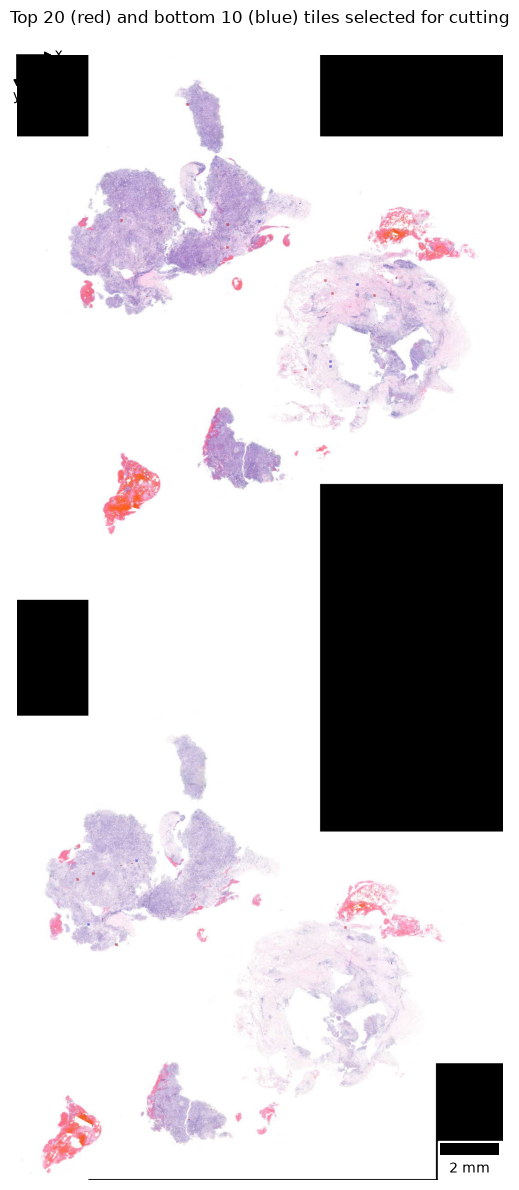

In [3]:
from roi_selection import ROISelector

slide = df_all["filename"].tolist()[1]

selector = ROISelector(cache_path = inference_path, slide_path = slide, top_k = 20, bottom_k = 10, top_pct = 0.10, bottom_pct = 0.10)
selector.tiles_to_cut()

In [4]:
top_polygons, bottom_polygons = selector.viewer_polygons()

In [5]:
import os

slide_name = os.path.splitext(os.path.basename(slide))[0]

annotations_path = os.path.join(lmd_dir, slide_name, 'annotations.json')
print(annotations_path)
screenshot_dir = os.path.join(lmd_dir, slide_name, 'calibration_points')
print(screenshot_dir)

D:\DATA\DVP1_lymphomas\lmd\12203779010101\annotations.json
D:\DATA\DVP1_lymphomas\lmd\12203779010101\calibration_points


In [6]:
from interactive_viewer import launch_calibration_viewer

viewer, url = launch_calibration_viewer(
    slide_path=slide,
    top_polygons=top_polygons,
    bottom_polygons=bottom_polygons,
    save_json=annotations_path,
    screenshot_dir=screenshot_dir,
    polygon_input_order="xy",
    open_browser=True,
)

=== WSI calibration viewer session ===
slide_path: \\regsj.intern\appl\Deep_Visual_Proteomics\Slides 02.04.2024\12203779010101.mrxs
slide_dimensions: (211712, 462080)
top_polygons: 20
bottom_polygons: 10
save_json: D:\DATA\DVP1_lymphomas\lmd\12203779010101\annotations.json
screenshot_dir: D:\DATA\DVP1_lymphomas\lmd\12203779010101\calibration_points
port: 64953
Viewer URL: http://127.0.0.1:64953/?session=3b194b692774448eb7935cba6594a8c3&slide=12203779010101.mrxs


In [ ]:
# Manually add calibration points (3 points, easy to locate on LMD)

In [8]:
selector.set_paths(annotations_path = annotations_path, lmd_dir = lmd_dir)

Set annotations path: D:\DATA\DVP1_lymphomas\lmd\12203779010101\annotations.json
Set LMD directory: D:\DATA\DVP1_lymphomas\lmd


In [9]:
sdata_lmd = selector.add_calibration_points()

In [10]:
sdata_lmd

SpatialData object
├── Images
│     └── 'wsi_thumbnail': DataArray[cyx] (3, 916, 420)
├── Points
│     └── 'calibration_points': DataFrame with shape: (<Delayed>, 2) (2D points)
└── Shapes
      ├── 'bottom_tiles': GeoDataFrame shape: (10, 3) (2D shapes)
      └── 'top_tiles': GeoDataFrame shape: (20, 3) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        wsi_thumbnail (Images), calibration_points (Points), bottom_tiles (Shapes), top_tiles (Shapes)

In [11]:
selector.write_to_lmd()

D:\DATA\DVP1_lymphomas\lmd\12203779010101\12203779010101_top.xml
[  61186. -123015.]
[  82722. -373946.]
[ 119589. -187515.]
Wrote LMD file for top tiles: D:\DATA\DVP1_lymphomas\lmd\12203779010101\12203779010101_top.xml
D:\DATA\DVP1_lymphomas\lmd\12203779010101\12203779010101_bottom.xml
[  61186. -123015.]
[  82722. -373946.]
[ 119589. -187515.]
Wrote LMD file for bottom tiles: D:\DATA\DVP1_lymphomas\lmd\12203779010101\12203779010101_bottom.xml
